In [3]:
import numpy as np

path0 = './'
filename = 'syntax_matched_sentences.txt'
threshold = 0.4  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if float(word_overlap) < threshold and tags1 == tags2:
                    data.append((sentence1, sentence2, tags1, word_overlap))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(f'{len(data)=}')
print(data[-1])

# removing entries with tag counts less than 5
from collections import Counter
tag_counts = Counter(tags for _, _, tags, _ in data)
data = [entry for entry in data if tag_counts[entry[2]] > 5]

print(f"Filtered size: {len(data)}")

len(data)=2369
('The old tradition and a custom changed gradually', 'The soft pillow and a blanket lay comfortably', 'DT JJ NN CC DT NN VBD RB', '0.375')
Filtered size: 2098


In [2]:
# Export sentences from the filtered dataset to sentences0.txt and sentences1.txt

sentences0 = [entry[0] for entry in data]
sentences1 = [entry[1] for entry in data]

with open('sentences0.txt', 'w') as f0:
  for sentence in sentences0:
    f0.write(sentence + '\n')

with open('sentences1.txt', 'w') as f1:
  for sentence in sentences1:
    f1.write(sentence + '\n')

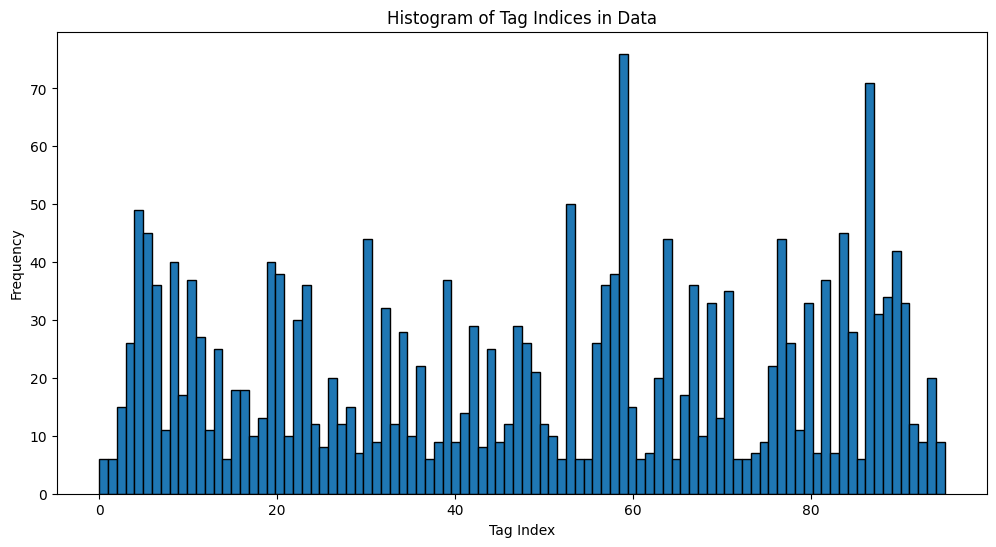

In [9]:
import matplotlib.pyplot as plt

# Assign an index to each unique tag in data
unique_tags = sorted(set(entry[2] for entry in data))
tag_to_index = {tag: idx for idx, tag in enumerate(unique_tags)}

# Get the list of tag indices for all entries in data
tag_indices = [tag_to_index[entry[2]] for entry in data]

# Plot histogram of tag indices
plt.figure(figsize=(12, 6))
plt.hist(tag_indices, bins=len(unique_tags), edgecolor='black')
plt.xlabel('Tag Index')
plt.ylabel('Frequency')
plt.title('Histogram of Tag Indices in Data')
plt.show()

In [10]:
np.savetxt('group_ids.txt',tag_indices,fmt='%d')

In [13]:
# Check if each sentence in sentences0 is also present in sentences1
sentences1_set = set(sentences1)
sentences0_in_1 = [sentence in sentences1_set for sentence in sentences0]

# Print summary
num_present = sum(sentences0_in_1)
print(f"{num_present} out of {len(sentences0)} sentences from sentences0.txt are present in sentences1.txt")

2063 out of 2098 sentences from sentences0.txt are present in sentences1.txt


In [11]:
### further filtering: to be present in the semantic dataset. 

In [12]:
# from collections import Counter
# import os # Import os module to get basename of file paths
# import random # Import random module for picking random sentences

# # --- Configuration ---
# path0 = './'
# filename = 'syntax_matched_sentences.txt'
# threshold = 0.4

# sentences_file0 = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences0.txt"
# sentences_file1 = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences1.txt"

# # --- Step 1: Load allowed sentences and map them to their line numbers AND source file identifier ---
# # The map will now store a tuple: (line_num, file_identifier)
# sentence_to_line_map = {}
# # Read from the first file
# with open(sentences_file0, 'r') as f:
#     # enumerate(f) defaults to starting from 0
#     for line_num, line in enumerate(f):
#         # Store a tuple of (line_number, '0' for sentences_file0)
#         sentence_to_line_map[line.strip()] = (line_num, '0')
        
# # Read from the second file, overwriting duplicates if any (and updating file identifier)
# with open(sentences_file1, 'r') as f:
#     # enumerate(f) defaults to starting from 0
#     for line_num, line in enumerate(f):
#         # Store a tuple of (line_number, '1' for sentences_file1)
#         sentence_to_line_map[line.strip()] = (line_num, '1')
        
# print(f"Loaded {len(sentence_to_line_map)} unique sentences to filter against.")

# # --- Step 2: Initial filtering from the source file ---
# data = []
# with open(f"{path0}{filename}", "r") as f:
#     for line in f:
#         parts = line.strip().split('\t')
#         if len(parts) == 5:
#             sentence1, sentence2, tags1, tags2, word_overlap = parts
#             if float(word_overlap) < threshold and tags1 == tags2:
#                 data.append((sentence1, sentence2, tags1, word_overlap))

# print(f"Size after initial overlap/tag filter: {len(data)}")

# # --- Step 3: Filter by tag frequency ---
# # Filters out entries where the associated tag appears 5 or fewer times in the dataset.
# tag_counts = Counter(tags for _, _, tags, _ in data)
# data = [entry for entry in data if tag_counts[entry[2]] > 5]
# print(f"Size after tag count filter: {len(data)}")

# # --- Step 4: Filter by sentence existence and ensure unique labels and matching data length ---
# # This step now ensures that both final_data and semantic_labels contain unique entries
# # (based on the label and file identifier) and that their lengths match.
# final_data = []
# # Use a set to track which (label, file_identifier) pairs have already been processed
# processed_label_identifiers = set() 
# semantic_labels_to_export = [] # This will store (label, file_identifier) tuples for export
# # New dictionary to map (label, file_identifier) to the original (sentence1, sentence2) from syntax file
# label_identifier_to_syntax_sentences_map = {}

# allowed_sentences_keys = sentence_to_line_map.keys()

# for entry in data: # 'data' here is the result of Step 3
#     sentence1, sentence2, _, _ = entry
    
#     current_label_identifier = None
#     if sentence1 in allowed_sentences_keys:
#         current_label_identifier = sentence_to_line_map[sentence1]
#     elif sentence2 in allowed_sentences_keys:
#         current_label_identifier = sentence_to_line_map[sentence2]

#     # Only add the entry to final_data and its label to semantic_labels_to_export
#     # if a valid label was found AND this (label, file_identifier) hasn't been processed yet.
#     if current_label_identifier and current_label_identifier not in processed_label_identifiers:
#         final_data.append(entry)
#         semantic_labels_to_export.append(current_label_identifier)
#         processed_label_identifiers.add(current_label_identifier)
#         # Store the original sentences from the syntax file for verification
#         label_identifier_to_syntax_sentences_map[current_label_identifier] = (sentence1, sentence2)

# # Update the main data list with the final filtered results
# data = final_data
# print(f"Size after sentence existence filter: {len(data)}")

# # Sort the labels for consistent output (e.g., by label then by identifier)
# semantic_labels_to_export.sort() 

# # --- Step 5: Export the semantic labels to a file ---
# # Writes the 0-indexed semantic labels and their corresponding file identifiers to the output file,
# # separated by a tab.
# output_filename = "semantic_labels.txt"
# with open(output_filename, 'w') as f:
#     for label_tuple in semantic_labels_to_export:
#         label, file_identifier = label_tuple
#         f.write(f"{label}\t{file_identifier}\n") # Using '0' or '1' as requested
        
# print(f"✅ Exported {len(semantic_labels_to_export)} labels to {output_filename}.")

# # --- Final Output ---
# print(f"\nFinal filtered size: {len(data)}")


# # --- Step 6: Verification - Pick 3 random labels and show corresponding sentences ---
# print("\n--- Verification: 3 Random Semantic Labels and Sentences ---")

# if not semantic_labels_to_export:
#     print("No semantic labels to verify.")
# else:
#     # Load sentences files into memory for quick lookup
#     try:
#         with open(sentences_file0, 'r') as f0:
#             all_sentences0 = f0.readlines()
#         with open(sentences_file1, 'r') as f1:
#             all_sentences1 = f1.readlines()
#     except FileNotFoundError as e:
#         print(f"Error during verification: Sentence file not found - {e}")
#     else:
#         num_samples = min(2, len(semantic_labels_to_export))
#         random_samples = random.sample(semantic_labels_to_export, num_samples)

#         for i, label_tuple in enumerate(random_samples):
#             label, file_identifier = label_tuple
#             retrieved_sentence = "N/A"
#             source_file_name = ""

#             # Get the original sentences from the syntax file that led to this label
#             syntax_sentence1, syntax_sentence2 = label_identifier_to_syntax_sentences_map.get(label_tuple, ("N/A", "N/A"))

#             if file_identifier == '0':
#                 source_file_name = os.path.basename(sentences_file0)
#                 if 0 <= label < len(all_sentences0):
#                     retrieved_sentence = all_sentences0[label].strip()
#             elif file_identifier == '1':
#                 source_file_name = os.path.basename(sentences_file1)
#                 if 0 <= label < len(all_sentences1):
#                     retrieved_sentence = all_sentences1[label].strip()
            
#             print(f"\nSample {i+1}:")
#             print(f"  Label (0-indexed): {label}")
#             print(f"  Source File ID: {file_identifier} ({source_file_name})")
#             print(f"  Original Sentence 1 (from syntax file): '{syntax_sentence1}'")
#             print(f"  Original Sentence 2 (from syntax file): '{syntax_sentence2}'")
#             print(f"  Retrieved Sentence (from semantic file): '{retrieved_sentence}'")

# print("\n--- Verification Complete ---")
